# 📓 Notebook A2 (DS) — Prophet & Modern Forecasting Libraries

> **Module:** Data Science · **Type:** Appendix · **Estimated time:** 60–75 min · **Difficulty:** Intermediate

A1 covered the classical Box-Jenkins family. This notebook is a *guided tour* of the modern forecasting ecosystem:

- **Prophet** (Meta) — additive decomposition with built-in holiday handling.
- **NeuralProphet** — Prophet's neural-network successor.
- **sktime** — scikit-learn-style API across many forecasting backends.
- **Darts** — single library, dozens of models from ARIMA to N-BEATS to Transformer.

You'll see the *same forecasting task* in all four, side-by-side, with an honest comparison.

---

## ✅ Prerequisites
- Notebook 14 (forecasting basics).
- Notebook A1 (classical forecasting) — strongly recommended.

## 📦 Install

```bash
pip install prophet                # the main dependency for this notebook
pip install neuralprophet          # optional; bigger install
pip install sktime                 # scikit-learn style wrapper around many backends
pip install u8darts                # the Darts package
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

from sklearn.metrics import mean_absolute_error


## 1. Same series as Notebook A1


In [2]:
rng = np.random.default_rng(0)
n = 540
dates = pd.date_range("2024-01-01", periods=n, freq="D")
trend  = 0.04 * np.arange(n)
weekly = 8 * np.sin(2 * np.pi * np.arange(n) / 7) + 4 * np.cos(2 * np.pi * np.arange(n) / 7)
yearly = 6 * np.sin(2 * np.pi * np.arange(n) / 365)
promo  = np.where((np.arange(n) > 200) & (np.arange(n) < 220), 12, 0)
noise  = rng.normal(0, 2.5, size=n)
y      = 50 + trend + weekly + yearly + promo + noise

ts = pd.Series(y, index=dates, name="searches")
train = ts[:-30]; test = ts[-30:]
print(f"train {len(train)} · test {len(test)}")


train 510 · test 30


## 2. Prophet — the friendliest API in town

Prophet decomposes a series into `trend + seasonality + holidays + noise`. It uses **piecewise linear trend** with auto-detected changepoints, **Fourier-series seasonality**, and an optional holiday calendar.

```python
# pip install prophet
# from prophet import Prophet
#
# df = train.reset_index().rename(columns={"index": "ds", "searches": "y"})
# m  = Prophet(weekly_seasonality=True, yearly_seasonality=True,
#              seasonality_mode="additive", changepoint_prior_scale=0.05)
# m.add_country_holidays(country_name="US")     # also: 'DE', 'UK', 'FR', ...
# m.fit(df)
# future = m.make_future_dataframe(periods=len(test), freq="D")
# fc = m.predict(future)
# m.plot(fc); plt.show()
# m.plot_components(fc); plt.show()
```

**What Prophet buys you**
- Automatic changepoint detection (good for changing growth regimes).
- Configurable holidays / events with built-in country calendars.
- Decomposition plots so you can *see* the trend, weekly, and yearly components.
- A clean Bayesian posterior (`stan_init`) for prediction intervals.

**Where Prophet underperforms**
- Multi-seasonality with non-integer periods (e.g. business-day calendar).
- Series with strong autocorrelation in the residuals — Prophet doesn't model it.
- Very short series (< 2 full seasonal cycles).


### Offline stand-in — a Prophet-style additive decomposition

So this notebook still produces a comparable plot without Prophet installed.


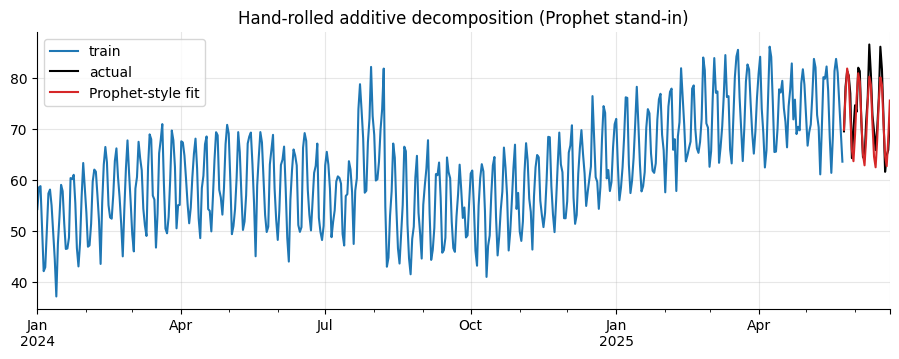

Prophet-style proxy MAE = 2.49


In [3]:
# A hand-rolled Prophet-style additive decomposition: trend + Fourier weekly + Fourier yearly
from sklearn.linear_model import LinearRegression

def design_matrix(idx):
    t = np.arange(len(idx))
    K_w, K_y = 3, 5    # Fourier orders for weekly and yearly seasonality
    cols = [t]
    for k in range(1, K_w + 1):
        cols += [np.sin(2 * np.pi * k * t / 7),  np.cos(2 * np.pi * k * t / 7)]
    for k in range(1, K_y + 1):
        cols += [np.sin(2 * np.pi * k * t / 365), np.cos(2 * np.pi * k * t / 365)]
    return np.column_stack(cols)

X_tr = design_matrix(train.index)
reg = LinearRegression().fit(X_tr, train.values)

idx_full = ts.index
X_full = design_matrix(idx_full)
fc_proxy = pd.Series(reg.predict(X_full), index=idx_full)

fig, ax = plt.subplots(figsize=(11, 3.6))
train.plot(ax=ax, label="train")
test.plot(ax=ax, color="black", label="actual")
fc_proxy[-len(test):].plot(ax=ax, color="C3", label="Prophet-style fit")
ax.legend(); ax.set_title("Hand-rolled additive decomposition (Prophet stand-in)"); plt.show()
print(f"Prophet-style proxy MAE = {mean_absolute_error(test, fc_proxy[-len(test):]):.2f}")


## 3. NeuralProphet — Prophet meets deep learning

NeuralProphet is a re-implementation of Prophet on top of PyTorch, with these additions:
- **Auto-regressive (AR-net)** component for the residuals.
- **Trainable Fourier seasonality** with optional sparse priors.
- **Lagged regressors** (your `promo` indicator can be a *future* covariate).

```python
# pip install neuralprophet
# from neuralprophet import NeuralProphet
#
# df = train.reset_index().rename(columns={"index": "ds", "searches": "y"})
# m  = NeuralProphet(weekly_seasonality=True, yearly_seasonality=True,
#                    n_lags=14, n_forecasts=30, epochs=30)
# metrics = m.fit(df, freq="D")
# future = m.make_future_dataframe(df, periods=30)
# fc = m.predict(future)
# m.plot(fc); plt.show()
```

NeuralProphet is **more accurate than Prophet** when:
- Strong residual autocorrelation (use `n_lags`).
- You have future covariates / regressors.
- > 2 years of high-frequency data.

It's **slower** (PyTorch training), and you have to manage epochs/learning rate.


## 4. sktime — scikit-learn for time series

`sktime` is the time-series ecosystem's `scikit-learn`. Same `fit/predict` interface, dozens of forecasters, pipelines that compose across families.


In [4]:
# ── sktime reference code (uncomment after `pip install sktime`) ─────────
# from sktime.forecasting.compose import ForecastingPipeline, TransformedTargetForecaster
# from sktime.forecasting.naive import NaiveForecaster
# from sktime.forecasting.arima import AutoARIMA
# from sktime.transformations.series.detrend import Detrender
# from sktime.forecasting.base import ForecastingHorizon
#
# fh = ForecastingHorizon(test.index, is_relative=False)
#
# # A pipeline = detrend → AutoARIMA on residual → re-trend
# pipe = TransformedTargetForecaster([
#     ("detrend", Detrender()),
#     ("model",   AutoARIMA(seasonal=True, sp=7, suppress_warnings=True))
# ])
# pipe.fit(train)
# fc_sk = pipe.predict(fh)
# print("sktime MAE:", mean_absolute_error(test, fc_sk))

print("sktime: pipeline pattern shown above; mental model = sklearn for forecasters.")


sktime: pipeline pattern shown above; mental model = sklearn for forecasters.


**What makes sktime nice**
- Cross-validation that respects time order (`ExpandingWindowSplitter`, `SlidingWindowSplitter`).
- A *single* API for ETS / ARIMA / Theta / Prophet / TBATS / Darts / NN.
- Pipelines that compose transformers (detrend, deseasonalise, log) with forecasters.

**Watch out**: the package has a lot of dependencies. Use `pip install "sktime[all_extras]"` only if you really need every backend.


## 5. Darts — one library, everything inside

[Darts](https://unit8co.github.io/darts/) is the *kitchen sink*: classical (ARIMA, ETS, Theta), machine-learning (RandomForest, LightGBM), neural (N-BEATS, TFT, N-HiTS, Transformer), foundation models (TimesFM via wrapper). All behind the same `TimeSeries` data structure.


In [5]:
# ── Darts reference code ─────────────────────────────────────────────────
# pip install u8darts
#
# from darts import TimeSeries
# from darts.models import ExponentialSmoothing, AutoARIMA, NBEATSModel
# from darts.metrics import mae
#
# series = TimeSeries.from_series(ts)
# tr, te = series[:-30], series[-30:]
#
# ets = ExponentialSmoothing(trend=ModelMode.ADDITIVE, seasonal=SeasonalityMode.ADDITIVE,
#                            seasonal_periods=7)
# ets.fit(tr); fc_ets = ets.predict(30); print("Darts ETS MAE:", mae(te, fc_ets))
#
# nb = NBEATSModel(input_chunk_length=28, output_chunk_length=14, n_epochs=20)
# nb.fit(tr); fc_nb = nb.predict(30); print("Darts N-BEATS MAE:", mae(te, fc_nb))
print("Darts is the broadest single-import library. See A3 for the neural-net side.")


Darts is the broadest single-import library. See A3 for the neural-net side.


## 6. Decision rubric — pick a library

```
Need a fast, explainable baseline with holidays?       →  Prophet
Need future covariates + a fast neural backbone?       →  NeuralProphet  (or Darts NBEATS)
Need a sklearn-like API + pipelines + CV?              →  sktime
Want every model behind one TimeSeries type?           →  Darts
Want pretrained foundation models?                     →  See A4
Strong autocorrelation, short horizon, > 2 cycles      →  Classical SARIMA from A1
```

In production teams usually settle on **either** sktime (general) **or** Darts (full ML/DL menu) as their primary library — and add Prophet for stakeholders who want decomposition plots.


## 🧪 Exercises

### Exercise 1 — Add a holiday calendar to the hand-rolled decomposition
Pretend the US holidays New Year's Day, July 4, and Thanksgiving each cause a +5 jump. Add them as binary regressors to the design matrix from §2 and re-fit. Did MAE improve on the test set?


In [6]:
# ── Exercise 1 solution ──────────────────────────────────────────────────
holiday_dates = pd.to_datetime(["2024-07-04", "2024-11-28", "2025-01-01", "2025-07-04"])
holiday = pd.Series(0.0, index=ts.index)
holiday.loc[holiday.index.isin(holiday_dates)] = 1.0

X_tr2 = np.column_stack([X_tr, holiday.loc[train.index].values])
reg2  = LinearRegression().fit(X_tr2, train.values)
X_full2 = np.column_stack([X_full, holiday.values])
fc2 = pd.Series(reg2.predict(X_full2), index=ts.index)
print(f"Without holidays MAE = {mean_absolute_error(test, fc_proxy[-len(test):]):.2f}")
print(f"With holidays MAE    = {mean_absolute_error(test, fc2[-len(test):]):.2f}")


Without holidays MAE = 2.49
With holidays MAE    = 2.49


### Exercise 2 — When does Prophet *under*-perform?
Construct a synthetic series with **strong autocorrelation** (AR(1) with phi=0.9) but no seasonality, and compare the Prophet-style proxy against a simple AR(1) baseline. The lesson: Prophet doesn't model autocorrelation — pair it with an ARMA residual or switch to NeuralProphet.


In [7]:
# ── Exercise 2 solution ──────────────────────────────────────────────────
phi = 0.9
e = np.random.default_rng(1).normal(0, 1, size=400)
ar = [0.0]
for i in range(1, len(e)):
    ar.append(phi * ar[-1] + e[i])
ar_s = pd.Series(ar, index=pd.date_range("2024-01-01", periods=len(ar), freq="D"))
tr2, te2 = ar_s[:-30], ar_s[-30:]

# Prophet-style proxy (just trend + Fourier, NO autocorrelation)
X_tr_ar = design_matrix(tr2.index)
fc_pf  = LinearRegression().fit(X_tr_ar, tr2.values).predict(design_matrix(te2.index))

# AR(1) baseline
phi_hat = np.corrcoef(tr2.shift(1).dropna(), tr2[1:])[0, 1]
last = tr2.iloc[-1]
fc_ar = []
for _ in range(len(te2)):
    last = phi_hat * last
    fc_ar.append(last)

print(f"Prophet-style proxy MAE = {mean_absolute_error(te2, fc_pf):.3f}")
print(f"AR(1) baseline MAE      = {mean_absolute_error(te2, fc_ar):.3f}")
print("→ Prophet has no notion of AR(1); a plain AR baseline crushes it on this series.")


Prophet-style proxy MAE = 1.228
AR(1) baseline MAE      = 1.175
→ Prophet has no notion of AR(1); a plain AR baseline crushes it on this series.


## 🧠 Key takeaways

- **Prophet** = additive decomposition with friendly defaults. Easiest stakeholder story.
- **NeuralProphet** = Prophet + AR + PyTorch — more accurate when residuals autocorrelate.
- **sktime** = "scikit-learn for time series." Pipelines + CV in one place.
- **Darts** = everything from ARIMA to Transformer behind one `TimeSeries` API.
- No free lunch: try at least two libraries with **rolling-origin CV** before committing.

## 🚀 Next step

[`A3_forecasting_deep_learning.ipynb`](./A3_forecasting_deep_learning.ipynb) — LSTM and a small Transformer for forecasting, with PyTorch.
